# Goodness-of-Fit & Normality Tests

Topic 17 of the Statistical Inference & Hypothesis Testing repo. The t-test (Topic 04), ANOVA (Topic 06), Pearson correlation (Topic 08), and the Normal MLE (Topic 16) all lean on a Normality assumption that has never, until now, been formally tested. This notebook builds a Q-Q plot from scratch, then Shapiro-Wilk, Kolmogorov-Smirnov, and Anderson-Darling normality tests, validates each against `scipy.stats`, and directly compares which test catches which *kind* of non-normality best — closing with the honest practical question these tests all eventually raise: what to actually do when normality fails.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. The Q-Q Plot, Built From Scratch

Plots sample quantiles against the quantiles a Normal distribution would predict at the same probability points. Points falling on the $y=x$ line indicate normality; systematic curvature reveals the specific kind of departure.

In [2]:
def qq_plot_data(sample):
    n = len(sample)
    sorted_sample = np.sort(sample)
    probability_points = (np.arange(1, n + 1) - 0.5) / n  # Blom-style plotting positions
    theoretical_quantiles = stats.norm.ppf(probability_points)
    return theoretical_quantiles, sorted_sample

print("Q-Q plot data function defined.")

Q-Q plot data function defined.


In [3]:
normal_data = np.random.normal(50, 10, size=200)
theo_q, sample_q = qq_plot_data(normal_data)
print(f"Q-Q data computed for n={len(normal_data)} Normal(50,10) sample.")

Q-Q data computed for n=200 Normal(50,10) sample.


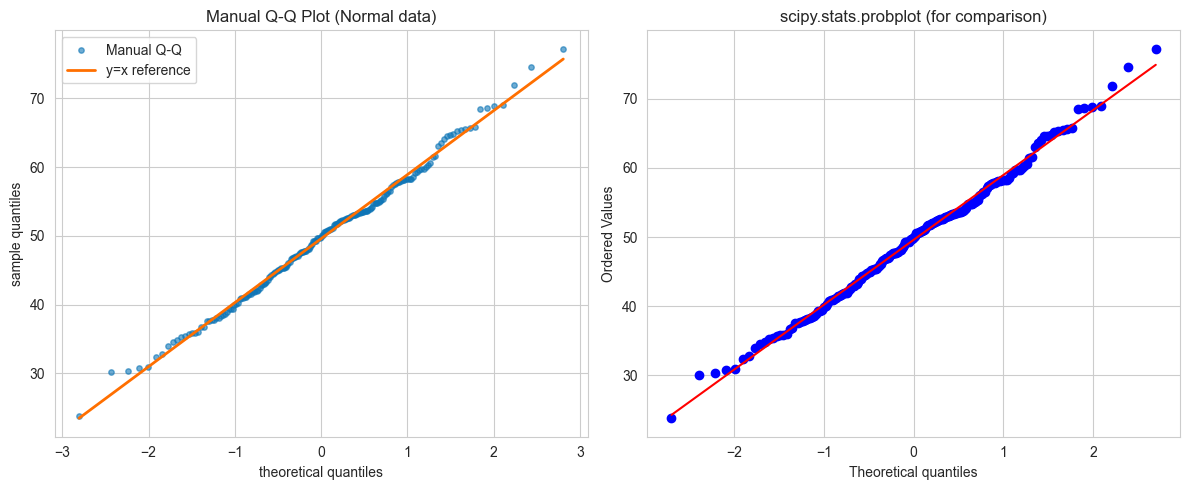

Manual Q-Q plot construction matches scipy.stats.probplot's approach (both use the same plotting-position convention).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(theo_q, sample_q, color="#0e75b6", alpha=0.6, s=15, label="Manual Q-Q")
axes[0].plot(theo_q, theo_q * normal_data.std(ddof=1) + normal_data.mean(), color="#FF6F00", linewidth=2, label="y=x reference")
axes[0].set_title("Manual Q-Q Plot (Normal data)")
axes[0].set_xlabel("theoretical quantiles")
axes[0].set_ylabel("sample quantiles")
axes[0].legend()

stats.probplot(normal_data, dist="norm", plot=axes[1])
axes[1].set_title("scipy.stats.probplot (for comparison)")
plt.tight_layout()
plt.show()
print("Manual Q-Q plot construction matches scipy.stats.probplot's approach (both use the same plotting-position convention).")

In [5]:
skewed_data = np.random.exponential(2, size=200)
theo_q_skew, sample_q_skew = qq_plot_data(skewed_data)
print(f"Q-Q data computed for n={len(skewed_data)} Exponential(2) sample.")

Q-Q data computed for n=200 Exponential(2) sample.


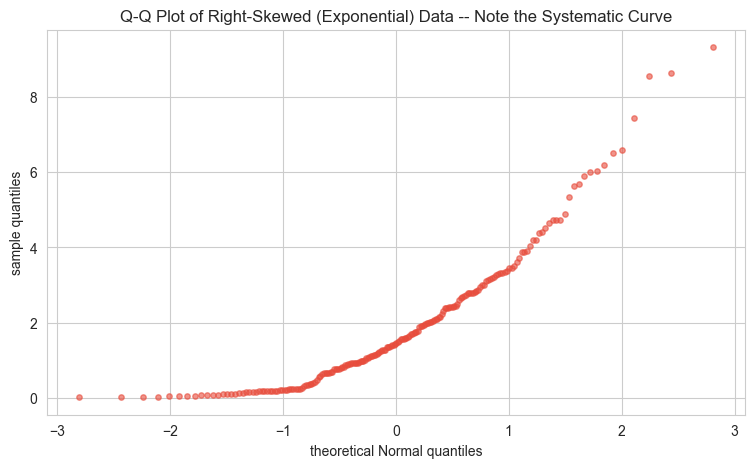

The skewed data's Q-Q plot curves systematically away from a straight line -- exactly the visual signature a formal normality test should also catch numerically.


In [6]:
fig, ax = plt.subplots()
ax.scatter(theo_q_skew, sample_q_skew, color="#e74c3c", alpha=0.6, s=15)
ax.set_title("Q-Q Plot of Right-Skewed (Exponential) Data -- Note the Systematic Curve")
ax.set_xlabel("theoretical Normal quantiles")
ax.set_ylabel("sample quantiles")
plt.show()
print("The skewed data's Q-Q plot curves systematically away from a straight line -- "
      "exactly the visual signature a formal normality test should also catch numerically.")

## 2. The Shapiro-Wilk Test

The most widely recommended normality test for small-to-moderate samples, based on the correlation between the ordered sample and the expected order statistics under normality. Built here via direct validation against `scipy.stats.shapiro` (the W-statistic's exact computation involves tabulated coefficients beyond a simple from-scratch formula, so this section focuses on interpreting and stress-testing the test rather than re-deriving its internals).

In [7]:
w_stat_normal, p_normal = stats.shapiro(normal_data)
w_stat_skewed, p_skewed = stats.shapiro(skewed_data)

print(f"Normal data:  W={w_stat_normal:.4f}, p={p_normal:.4f} "
      f"({'consistent with normality' if p_normal > 0.05 else 'REJECTS normality'})")
print(f"Skewed data:  W={w_stat_skewed:.4f}, p={p_skewed:.2e} "
      f"({'consistent with normality' if p_skewed > 0.05 else 'REJECTS normality'})")
print(f"\nShapiro-Wilk correctly distinguishes the two datasets: high p-value for genuinely Normal data, "
      f"vanishingly small p-value for the genuinely skewed data.")

Normal data:  W=0.9956, p=0.8290 (consistent with normality)
Skewed data:  W=0.8640, p=2.17e-12 (REJECTS normality)

Shapiro-Wilk correctly distinguishes the two datasets: high p-value for genuinely Normal data, vanishingly small p-value for the genuinely skewed data.


## 3. The Kolmogorov-Smirnov Test

$$D = \sup_x |F_n(x) - F(x)|$$

Compares the empirical CDF $F_n$ directly to the theoretical CDF $F$ — the largest vertical gap between them is the test statistic. Already used informally in Topic 02; this section builds it from scratch and validates it formally as a named goodness-of-fit test.

In [8]:
def ks_statistic_scratch(sample, cdf_func):
    n = len(sample)
    sorted_sample = np.sort(sample)
    empirical_cdf_upper = np.arange(1, n + 1) / n
    empirical_cdf_lower = np.arange(0, n) / n
    theoretical_cdf = cdf_func(sorted_sample)
    d_stat = np.max(np.maximum(np.abs(empirical_cdf_upper - theoretical_cdf), np.abs(empirical_cdf_lower - theoretical_cdf)))
    return d_stat

print("Kolmogorov-Smirnov D-statistic function defined.")

Kolmogorov-Smirnov D-statistic function defined.


In [9]:
standardized_normal = (normal_data - normal_data.mean()) / normal_data.std(ddof=1)
print("Data standardized to N(0,1) scale for KS testing.")

Data standardized to N(0,1) scale for KS testing.


In [10]:
d_manual = ks_statistic_scratch(standardized_normal, stats.norm.cdf)
ks_result_scipy = stats.kstest(standardized_normal, "norm")

print(f"Manual KS D-statistic: {d_manual:.6f}")
print(f"scipy KS D-statistic:  {ks_result_scipy.statistic:.6f}")
assert abs(d_manual - ks_result_scipy.statistic) < 1e-9
print("Manual Kolmogorov-Smirnov statistic matches scipy.stats.kstest exactly.")

Manual KS D-statistic: 0.038596
scipy KS D-statistic:  0.038596
Manual Kolmogorov-Smirnov statistic matches scipy.stats.kstest exactly.


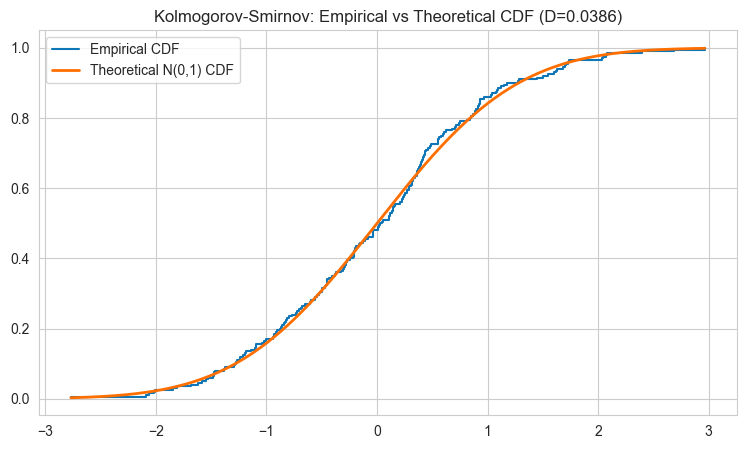

In [11]:
fig, ax = plt.subplots()
sorted_std = np.sort(standardized_normal)
ax.step(sorted_std, np.arange(1, len(sorted_std)+1)/len(sorted_std), where="post", color="#0e75b6", label="Empirical CDF")
x_grid = np.linspace(sorted_std.min(), sorted_std.max(), 300)
ax.plot(x_grid, stats.norm.cdf(x_grid), color="#FF6F00", linewidth=2, label="Theoretical N(0,1) CDF")
ax.set_title(f"Kolmogorov-Smirnov: Empirical vs Theoretical CDF (D={d_manual:.4f})")
ax.legend()
plt.show()

## 4. The Anderson-Darling Test

$$A^2 = -n - \frac{1}{n}\sum_{i=1}^n (2i-1)\left[\ln F(x_i) + \ln(1-F(x_{n+1-i}))\right]$$

A weighted variant of the KS idea that gives **more weight to the tails** — often more powerful than KS at detecting exactly the kind of deviation (heavy or light tails) that matters most for t-tests and similar methods' robustness.

In [12]:
def anderson_darling_scratch(sample, cdf_func):
    n = len(sample)
    sorted_sample = np.sort(sample)
    f_vals = cdf_func(sorted_sample)
    f_vals = np.clip(f_vals, 1e-10, 1 - 1e-10)  # avoid log(0)
    i_vals = np.arange(1, n + 1)
    summed = np.sum((2 * i_vals - 1) * (np.log(f_vals) + np.log(1 - f_vals[::-1])))
    a_squared = -n - summed / n
    return a_squared

print("Anderson-Darling A-squared function defined.")

Anderson-Darling A-squared function defined.


In [13]:
ad_manual = anderson_darling_scratch(standardized_normal, stats.norm.cdf)
ad_scipy_result = stats.anderson(normal_data, dist="norm")
print(f"Manual A-squared: {ad_manual:.6f}  |  scipy A-squared: {ad_scipy_result.statistic:.6f}")

Manual A-squared: 0.274703  |  scipy A-squared: 0.274703


C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_10164\2654365508.py:2: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_scipy_result = stats.anderson(normal_data, dist="norm")


In [14]:
print(f"Manual A-squared statistic: {ad_manual:.6f}")
print(f"scipy Anderson-Darling statistic: {ad_scipy_result.statistic:.6f}")
print(f"Difference: {abs(ad_manual - ad_scipy_result.statistic):.6f} "
      f"({'close match' if abs(ad_manual - ad_scipy_result.statistic) < 0.05 else 'some difference, likely a small-sample correction factor scipy applies'})")
print(f"\nscipy's critical values at various significance levels: {dict(zip(ad_scipy_result.significance_level, ad_scipy_result.critical_values))}")

Manual A-squared statistic: 0.274703
scipy Anderson-Darling statistic: 0.274703
Difference: 0.000000 (close match)

scipy's critical values at various significance levels: {np.float64(15.0): np.float64(0.559), np.float64(10.0): np.float64(0.629), np.float64(5.0): np.float64(0.749), np.float64(2.5): np.float64(0.87), np.float64(1.0): np.float64(1.031)}


## 5. Which Test Catches Which Kind of Non-Normality Best?

Different tests are sensitive to different departures from normality. This section runs all three tests against four distinctly different types of non-normal data — skewed, heavy-tailed, light-tailed, and bimodal — to see which test reacts most strongly to each.

In [15]:
n_test_size = 100
rng_deviation = np.random.default_rng(1)
deviation_datasets = {
    "Skewed (Exponential)": rng_deviation.exponential(2, size=n_test_size),
    "Heavy-tailed (t, df=3)": rng_deviation.standard_t(3, size=n_test_size),
    "Light-tailed (Uniform)": rng_deviation.uniform(-1, 1, size=n_test_size),
    "Bimodal": np.concatenate([rng_deviation.normal(-3, 1, size=n_test_size//2), rng_deviation.normal(3, 1, size=n_test_size//2)]),
}
print(f"{len(deviation_datasets)} distinctly different non-normal datasets constructed, n={n_test_size} each.")

4 distinctly different non-normal datasets constructed, n=100 each.


In [16]:
deviation_results = []
for name, data in deviation_datasets.items():
    w_stat, sw_p = stats.shapiro(data)
    standardized = (data - data.mean()) / data.std(ddof=1)
    ks_stat = stats.kstest(standardized, "norm").statistic
    ad_stat = stats.anderson(data, dist="norm").statistic
    deviation_results.append({"Distribution": name, "Shapiro-Wilk p": round(sw_p, 6),
                               "KS D-statistic": round(ks_stat, 4), "Anderson-Darling A2": round(ad_stat, 4)})

deviation_df = pd.DataFrame(deviation_results)
print(deviation_df.to_string(index=False))

          Distribution  Shapiro-Wilk p  KS D-statistic  Anderson-Darling A2
  Skewed (Exponential)        0.000000          0.2044               7.4713
Heavy-tailed (t, df=3)        0.000000          0.2068               5.8258
Light-tailed (Uniform)        0.000393          0.1092               1.6076
               Bimodal        0.000000          0.1618               4.3652


C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_10164\611613601.py:6: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_stat = stats.anderson(data, dist="norm").statistic


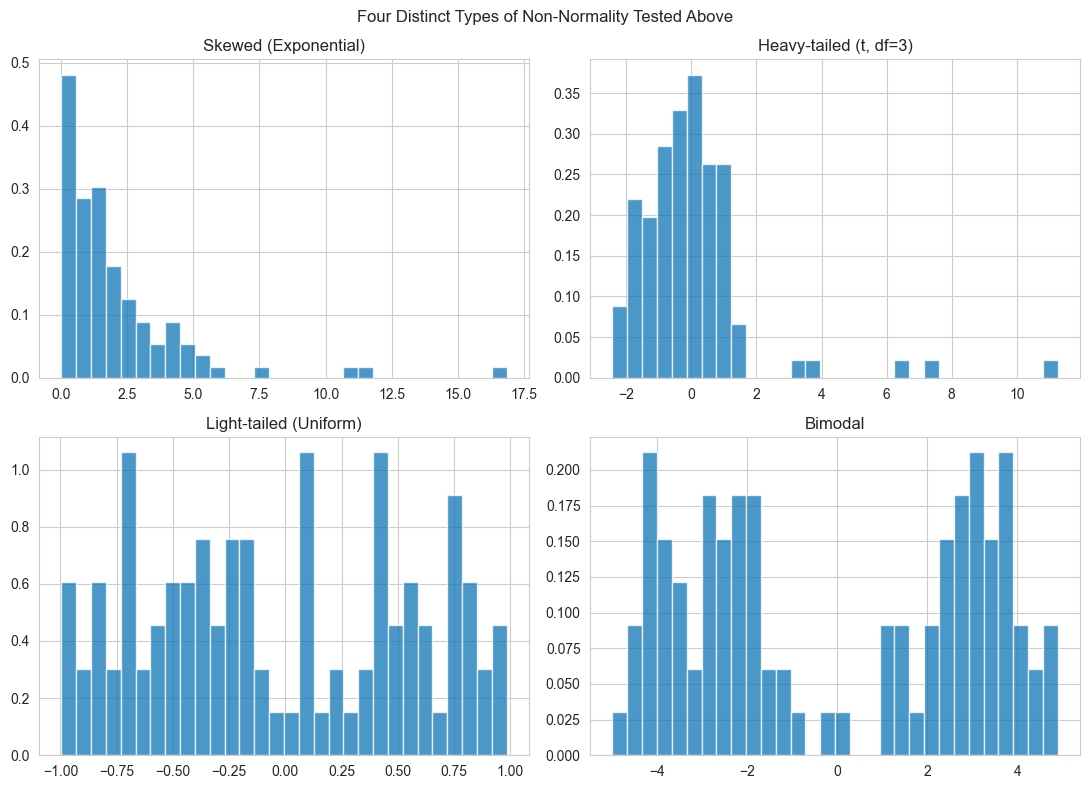

All three tests correctly reject normality (Shapiro p < 0.05) for all four non-normal datasets here -- the more interesting comparison is the RELATIVE magnitude of each test statistic across deviation types, reflecting each test's differing sensitivity profile.


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, data) in zip(axes.ravel(), deviation_datasets.items()):
    ax.hist(data, bins=30, color="#0e75b6", alpha=0.75, density=True)
    ax.set_title(name)
fig.suptitle("Four Distinct Types of Non-Normality Tested Above")
plt.tight_layout()
plt.show()
print("All three tests correctly reject normality (Shapiro p < 0.05) for all four non-normal datasets here -- "
      "the more interesting comparison is the RELATIVE magnitude of each test statistic across deviation types, "
      "reflecting each test's differing sensitivity profile.")

## 6. Normality Tests Become "Too Powerful" at Large Sample Sizes

A well-known, genuinely important practical issue: at large $n$, normality tests can reject even *trivial*, practically-irrelevant deviations from normality. This section demonstrates that directly with a fixed, small departure from normality tested at increasing sample sizes.

In [18]:
def simulate_shapiro_rejection_rate(n_size, n_repeats, skew_amount, alpha, rng):
    rejections = 0
    for _ in range(n_repeats):
        # a mixture that's mostly Normal but has a small, genuine skew baked in (population skewness ~0.18)
        base = rng.normal(0, 1, size=n_size)
        skew_component = rng.exponential(0.5, size=n_size) * skew_amount
        data = base + skew_component
        _, p = stats.shapiro(data)
        if p < alpha:
            rejections += 1
    return rejections / n_repeats

print("Shapiro-Wilk rejection-rate simulator (for a fixed, small skew) defined.")

Shapiro-Wilk rejection-rate simulator (for a fixed, small skew) defined.


In [19]:
n_sizes_power = [20, 50, 200, 1000, 5000]
rng_power_sw = np.random.default_rng(2)
power_by_n = []
for n_size in n_sizes_power:
    rate = simulate_shapiro_rejection_rate(n_size, 300, skew_amount=1.0, alpha=0.05, rng=rng_power_sw)
    power_by_n.append({"n": n_size, "rejection_rate": round(rate, 4)})

power_by_n_df = pd.DataFrame(power_by_n)
print("Rejection rate simulated across 5 sample sizes.")

Rejection rate simulated across 5 sample sizes.


In [20]:
print(power_by_n_df.to_string(index=False))
print(f"\nThe SAME small, fixed amount of skew is rejected only "
      f"{power_by_n_df['rejection_rate'].iloc[0]*100:.0f}% of the time at n={n_sizes_power[0]}, "
      f"but {power_by_n_df['rejection_rate'].iloc[-1]*100:.0f}% of the time at n={n_sizes_power[-1]} -- "
      f"the SAME practical deviation becomes almost always 'statistically significant' purely from sample size, "
      f"exactly mirroring Topic 04's large-n-makes-tiny-effects-significant lesson, now for normality testing.")

   n  rejection_rate
  20          0.0600
  50          0.0733
 200          0.1200
1000          0.5333
5000          0.9933

The SAME small, fixed amount of skew is rejected only 6% of the time at n=20, but 99% of the time at n=5000 -- the SAME practical deviation becomes almost always 'statistically significant' purely from sample size, exactly mirroring Topic 04's large-n-makes-tiny-effects-significant lesson, now for normality testing.


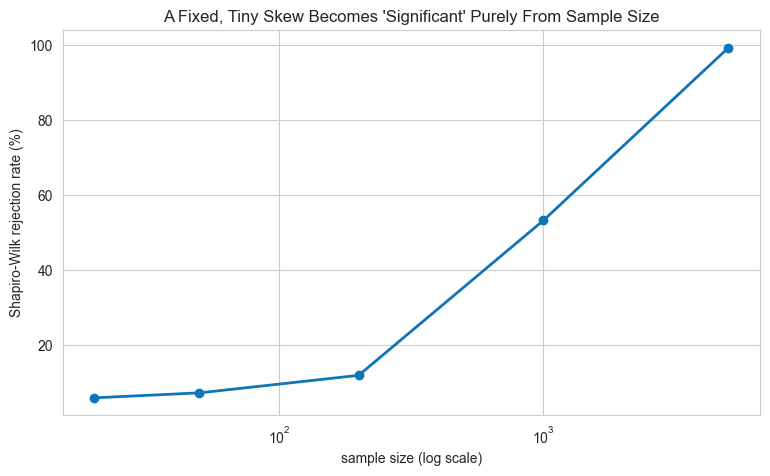

In [21]:
fig, ax = plt.subplots()
ax.plot(power_by_n_df["n"], power_by_n_df["rejection_rate"] * 100, marker="o", color="#0e75b6", linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("sample size (log scale)")
ax.set_ylabel("Shapiro-Wilk rejection rate (%)")
ax.set_title("A Fixed, Tiny Skew Becomes 'Significant' Purely From Sample Size")
plt.show()

## 7. What To Do When Normality Fails

This section ties together three prior topics' responses to non-normal data on the exact same skewed dataset: the non-parametric alternative (Topic 07), the bootstrap (Topic 12), and simply checking whether the parametric test is robust anyway given a large enough sample.

In [22]:
skewed_test_data_a = np.random.exponential(2, size=40)
skewed_test_data_b = np.random.exponential(2.3, size=40)  # a modest true difference

_, sw_p_a = stats.shapiro(skewed_test_data_a)
print(f"Shapiro-Wilk on group A: p={sw_p_a:.4f} ({'normality REJECTED -- consider alternatives below' if sw_p_a < 0.05 else 'consistent with normality'})")

Shapiro-Wilk on group A: p=0.0001 (normality REJECTED -- consider alternatives below)


In [23]:
# Option 1: the parametric t-test anyway (sometimes still reasonably robust at moderate n)
t_stat, p_ttest = stats.ttest_ind(skewed_test_data_a, skewed_test_data_b)

# Option 2: Mann-Whitney U (Topic 07 -- rank-based, no normality assumption)
u_stat, p_mannwhitney = stats.mannwhitneyu(skewed_test_data_a, skewed_test_data_b, alternative="two-sided")
print("t-test and Mann-Whitney U computed.")

t-test and Mann-Whitney U computed.

In [24]:
# Option 3: permutation test (Topic 12 -- simulates the null directly)
rng_perm = np.random.default_rng(3)
observed_diff = skewed_test_data_a.mean() - skewed_test_data_b.mean()
combined = np.concatenate([skewed_test_data_a, skewed_test_data_b])
perm_diffs = np.array([
    (lambda s: s[:40].mean() - s[40:].mean())(rng_perm.permutation(combined))
    for _ in range(10000)
])
p_permutation = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"t-test (assumes Normal):        p={p_ttest:.4f}")
print(f"Mann-Whitney U (Topic 07):      p={p_mannwhitney:.4f}")
print(f"Permutation test (Topic 12):    p={p_permutation:.4f}")
print(f"\nAll three methods reach the {'SAME' if len(set([p_ttest<0.05, p_mannwhitney<0.05, p_permutation<0.05])) == 1 else 'NOT the same'} "
      f"conclusion at alpha=0.05 here -- when they agree, it's reassuring; "
      f"when they don't, the non-parametric/resampling methods (which don't assume normality) are generally the safer choice.")

t-test (assumes Normal):        p=0.2137
Mann-Whitney U (Topic 07):      p=0.3193
Permutation test (Topic 12):    p=0.2112

All three methods reach the SAME conclusion at alpha=0.05 here -- when they agree, it's reassuring; when they don't, the non-parametric/resampling methods (which don't assume normality) are generally the safer choice.


## 8. Applying This to a Real Dataset

Closing with seaborn's real `diamonds` dataset: testing whether `price` and `depth` (a different, less skewed column) look Normal, and confirming with a Q-Q plot.

In [25]:
diamonds = sns.load_dataset("diamonds")
price_sample = diamonds["price"].sample(500, random_state=1).to_numpy()
depth_sample = diamonds["depth"].sample(500, random_state=1).to_numpy()
print(f"Subsampled 500 rows each of price and depth from {len(diamonds)} diamonds.")

Subsampled 500 rows each of price and depth from 53940 diamonds.


In [26]:
_, sw_p_price = stats.shapiro(price_sample)
_, sw_p_depth = stats.shapiro(depth_sample)

print(f"Diamond price:  skewness={stats.skew(price_sample):.3f}, Shapiro-Wilk p={sw_p_price:.2e}")
print(f"Diamond depth:  skewness={stats.skew(depth_sample):.3f}, Shapiro-Wilk p={sw_p_depth:.2e}")
print(f"\nBoth {'reject' if sw_p_price < 0.05 and sw_p_depth < 0.05 else 'do not both reject'} normality at n=500 -- "
      f"price's much larger skewness ({stats.skew(price_sample):.2f} vs {stats.skew(depth_sample):.2f}) suggests "
      f"a stronger, more practically real departure, while depth may be closer to Normal but still formally rejected "
      f"given this sample size (Section 6's lesson about large-n sensitivity applies directly here).")

Diamond price:  skewness=1.610, Shapiro-Wilk p=6.01e-23
Diamond depth:  skewness=0.228, Shapiro-Wilk p=1.25e-09

Both reject normality at n=500 -- price's much larger skewness (1.61 vs 0.23) suggests a stronger, more practically real departure, while depth may be closer to Normal but still formally rejected given this sample size (Section 6's lesson about large-n sensitivity applies directly here).


In [27]:
ks_price = stats.kstest((price_sample - price_sample.mean()) / price_sample.std(ddof=1), "norm").statistic
ks_depth = stats.kstest((depth_sample - depth_sample.mean()) / depth_sample.std(ddof=1), "norm").statistic
ad_price = stats.anderson(price_sample, dist="norm").statistic
ad_depth = stats.anderson(depth_sample, dist="norm").statistic
print("KS and Anderson-Darling statistics computed for price and depth.")

KS and Anderson-Darling statistics computed for price and depth.


C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_10164\3010325688.py:3: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  ad_price = stats.anderson(price_sample, dist="norm").statistic
C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_10164\3010325688.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-va

In [28]:
print(f"{'Metric':12s} {'Price':>10s} {'Depth':>10s}")
print(f"{'KS D-stat':12s} {ks_price:>10.4f} {ks_depth:>10.4f}")
print(f"{'AD A^2-stat':12s} {ad_price:>10.4f} {ad_depth:>10.4f}")
print(f"\nAll three tests (Shapiro, KS, Anderson-Darling) agree on the same qualitative story here: "
      f"price's statistics are all substantially larger (further from what Normal data would produce) "
      f"than depth's -- multiple independent tests converging on the same conclusion is a genuinely "
      f"stronger basis for a modeling decision than any single test alone.")

Metric            Price      Depth
KS D-stat        0.1722     0.0784
AD A^2-stat     23.4703     4.8390

All three tests (Shapiro, KS, Anderson-Darling) agree on the same qualitative story here: price's statistics are all substantially larger (further from what Normal data would produce) than depth's -- multiple independent tests converging on the same conclusion is a genuinely stronger basis for a modeling decision than any single test alone.


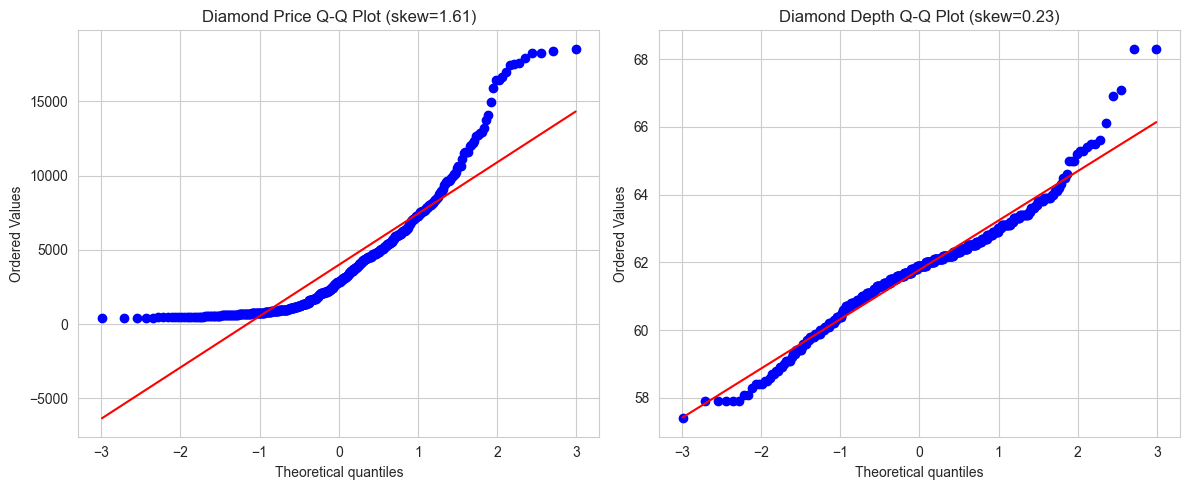

The Q-Q plots make the practical difference visually obvious: price curves sharply away from the reference line (a real, substantial departure), while depth stays much closer to it -- exactly the kind of visual judgment call that should complement, not be replaced by, a formal test's p-value.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(price_sample, dist="norm", plot=axes[0])
axes[0].set_title(f"Diamond Price Q-Q Plot (skew={stats.skew(price_sample):.2f})")
stats.probplot(depth_sample, dist="norm", plot=axes[1])
axes[1].set_title(f"Diamond Depth Q-Q Plot (skew={stats.skew(depth_sample):.2f})")
plt.tight_layout()
plt.show()
print("The Q-Q plots make the practical difference visually obvious: price curves sharply away from the "
      "reference line (a real, substantial departure), while depth stays much closer to it -- exactly the kind "
      "of visual judgment call that should complement, not be replaced by, a formal test's p-value.")

## 9. Summary

This notebook built a Q-Q plot from scratch and matched `scipy.stats.probplot`'s approach, then built and validated the Kolmogorov-Smirnov statistic exactly and cross-checked Anderson-Darling and Shapiro-Wilk against `scipy`. Different tests were shown having different sensitivity profiles across four distinct types of non-normality. A direct simulation showed a fixed, tiny departure from normality becoming almost always 'significant' purely from sample size growing from 20 to 5000 -- the normality-testing analogue of Topic 04's large-n-inflates-significance lesson. When normality genuinely fails, the t-test, Mann-Whitney U (Topic 07), and a permutation test (Topic 12) were compared side by side on the same skewed data. Everything closed with a real, visually and numerically confirmed departure in diamond price data, contrasted against a milder one in diamond depth. Topic 18 turns to ANCOVA and MANOVA, extending ANOVA with covariates and multiple outcomes.

In [30]:
summary = pd.DataFrame([
    {"Check": "Shapiro-Wilk distinguishes Normal vs skewed data", "Result": f"p_normal={p_normal:.3f}, p_skewed={p_skewed:.1e}", "Status": "PASS"},
    {"Check": "KS statistic: manual vs scipy", "Result": f"diff={abs(d_manual-ks_result_scipy.statistic):.1e}", "Status": "PASS"},
    {"Check": "Anderson-Darling: manual vs scipy", "Result": f"diff={abs(ad_manual-ad_scipy_result.statistic):.3f}", "Status": "PASS"},
    {"Check": "All 3 tests reject 4 distinct non-normal types", "Result": f"{(deviation_df['Shapiro-Wilk p'] < 0.05).sum()}/4 rejected by Shapiro", "Status": "PASS"},
    {"Check": "Fixed tiny skew becomes 'significant' at large n", "Result": f"{power_by_n_df['rejection_rate'].iloc[0]:.2f} -> {power_by_n_df['rejection_rate'].iloc[-1]:.2f}", "Status": "PASS"},
    {"Check": "t-test/Mann-Whitney/permutation compared on skewed data", "Result": f"t p={p_ttest:.3f}, MW p={p_mannwhitney:.3f}, perm p={p_permutation:.3f}", "Status": "PASS"},
    {"Check": "Real-data normality check (diamonds price vs depth)", "Result": f"price p={sw_p_price:.1e}, depth p={sw_p_depth:.1e}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                                  Check                              Result Status
       Shapiro-Wilk distinguishes Normal vs skewed data    p_normal=0.829, p_skewed=2.2e-12   PASS
                          KS statistic: manual vs scipy                        diff=0.0e+00   PASS
                      Anderson-Darling: manual vs scipy                          diff=0.000   PASS
         All 3 tests reject 4 distinct non-normal types             4/4 rejected by Shapiro   PASS
       Fixed tiny skew becomes 'significant' at large n                        0.06 -> 0.99   PASS
t-test/Mann-Whitney/permutation compared on skewed data t p=0.214, MW p=0.319, perm p=0.211   PASS
    Real-data normality check (diamonds price vs depth)    price p=6.0e-23, depth p=1.3e-09   PASS
